In [2]:
import numpy as np, pandas as pd
import seaborn as sns, matplotlib.pyplot as plt

In [3]:
#generate random dataset
np.random.seed(42)
n = 300
pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n) 
kota = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)
gaji = (3.0 + 2.2 * pengalaman + 1.5 * edu + np.where(kota == 'Jakarta', 4.0, 0)) + np.random.normal(0, 2.0, n)

In [33]:
df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})


print('Shape dataset:', df.shape)
print(df.describe().round(2))

Shape dataset: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.get_dummies(df, columns=['kota'],drop_first=True, dtype=int)
x = df.drop('gaji', axis=1)
y = df['gaji']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print('Shape X_train:', X_train.shape[0], 'Shape X_test:', X_test.shape[0])

Shape X_train: 240 Shape X_test: 60


In [36]:
#scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Tampilkan koefisien
print(f'β0 (intercept): {model.intercept_:.3f}')
print()
coef_df = pd.DataFrame({
'Fitur' : x.columns,
'Koefisien' : model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))

# Interpretasi: fitur mana yang paling berpengaruh?
# Koefisien positif → gaji naik
# Koefisien negatif → gaji turun


β0 (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


Berdasarkan koefisien diatas, yang paling berpengaruh adalah pengalaman, dilanjut dengan kota jakarta, lalu edukasi

In [ ]:
from sklearn.metrics import (mean_absolute_error,
mean_squared_error, r2_score)
y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print('=== Metrik Evaluasi ===')
print(f'MAE = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R2 = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')

# Interpretasikan dalam Markdown sel berikutnya:
# - Berapa rata-rata kesalahan prediksi dalam rupiah?
# - Apakah R2 cukup baik untuk kasus ini?
# - Apakah ada indikasi outlier?

=== Metrik Evaluasi ===
MAE = 1.649 juta rupiah
RMSE = 4.507 juta rupiah
R2 = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 2.857


1. Rata-rata kesalahan prediksi dalam rupiah, diambil dari nilai MAE (Mean Absolute error) adalah 1.65 juta rupiah dari nilai sebenarnya
2. R2 nya adalah 0.974, atau 97.4%. Nilai yang sangat tinggi dan dari data dapat disimpulkan bahwa model mampu melakukan prediksi dengan baik
3. Terdapat selisih sekitar 2.857 juta rupiah antara value RMSE dengan MAE. nilai RMSE yang jauh lebih tinggi dari MAE mengindikasikan bahwa ada beberapa outlier

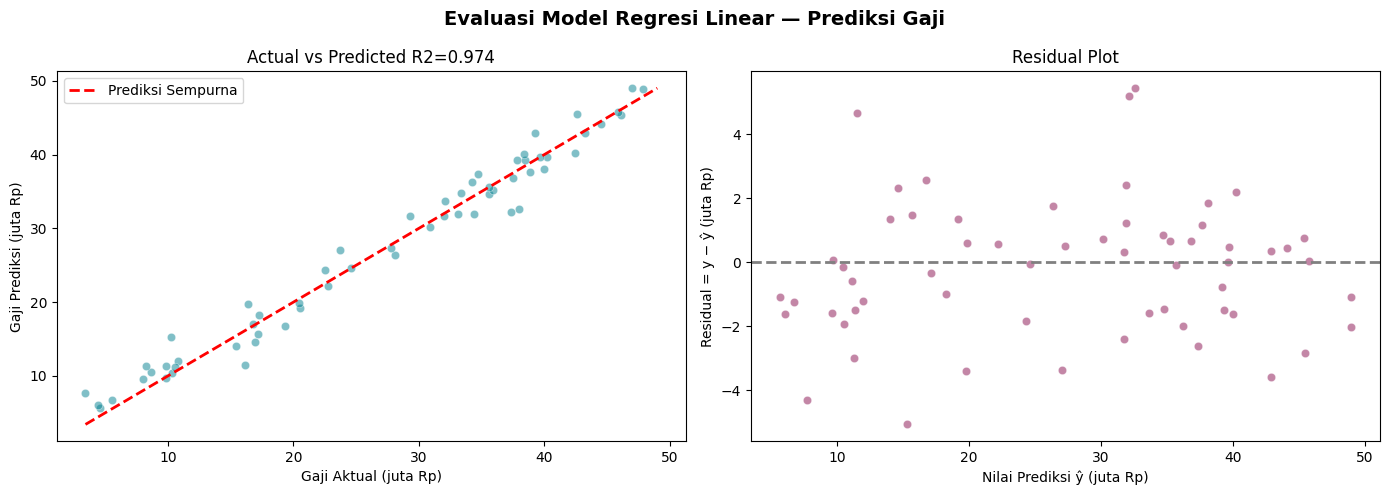

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5,
color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()),
max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2,
label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted R2={r2:.3f}')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5,
color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')
plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji',
fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()

#trigger commit

# What?
- R2 adalah 0.974, dan dari grafik diatas semua titik mendekati garis/prediksi sempurna dari linear regresi
- MAE adalah 1.649 juta, yang berarti rata rata kesalahan prediksi adalah di 1.65 juta
- RMSE adalah 4.5 juta, yang berarti ada beberapa prediksi meleset cukup jauh hingga RMSE menjadi lebih besar dibanding MAE
- Titik tersebar acak mendekati garis pada residual plot tanpa adanya kurva, yang berarti model ini memenuhi asumsi linearitas

# So What?
- Dataset ini cocok untuk menggunakan model linear, dikarenakan R2 yang tinggi, Prediksi mengikuti nilai aktual, dan residual tersebar acak di sekitar nol
- ada beberapa observasi yang menghasilkan error besar, dengan kecenderungan outlier

# Now What?
- Investigasi observasi dengan residual terbesar
- Tambahkan fitur fitur relevan untuk meningkatkan akurasi
- Bandingkan dengan model lain seperti Random Forest, XGBoost, Gradient Boosting untuk mencari model dengan akurasi tertinggi